# Step 1: Missing Values

In [15]:
# Create a dataset
import numpy as np
import pandas as pd
data = {'Age' : [25, 30, np.nan, 35, 0, 40],
        'Salary' : [50000, 60000, 55000, np.nan, 80000, -1],
        'Purchased' : ['No', 'Yes', None, 'Yes', 'Yes', 'yes']
}
df = pd.DataFrame(data)
df
# This is real-world messy data.

# Problems:
# NaN
# None
# 0 (invalid age)
# -1 (invalid salary)
# Yes vs yes (case issue)

,Age,Salary,Purchased
0,25.0,50000.0,No
1,30.0,60000.0,Yes
2,NaN,55000.0,None
3,35.0,NaN,Yes
4,0.0,80000.0,Yes
5,40.0,-1.0,yes


# First Cleaning Step - Check missing values

In [16]:
df.isnull().sum()

Age          1
Salary       1
Purchased    1
dtype: int64

In [17]:
df.isna().sum()

Age          1
Salary       1
Purchased    1
dtype: int64

# Standardize Missing Values

In [18]:
df['Age'] = df['Age'].replace(0, np.nan)
df['Salary'] = df['Salary'].replace(-1, np.nan)
df['Purchased'] = df['Purchased'].str.capitalize()
df

,Age,Salary,Purchased
0,25.0,50000.0,No
1,30.0,60000.0,Yes
2,NaN,55000.0,None
3,35.0,NaN,Yes
4,NaN,80000.0,Yes
5,40.0,NaN,Yes


# Check Missing Values Again

In [19]:
df.isnull().sum()

Age          2
Salary       2
Purchased    1
dtype: int64

In [20]:
df.isna().sum()

Age          2
Salary       2
Purchased    1
dtype: int64

# Handle Missing Numerical Values

In [21]:
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Salary'] = df['Salary'].fillna(df['Salary'].mean())
df['Purchased'] = df['Purchased'].fillna('No')
df

,Age,Salary,Purchased
0,25.0,50000.0,No
1,30.0,60000.0,Yes
2,32.5,55000.0,No
3,35.0,61250.0,Yes
4,32.5,80000.0,Yes
5,40.0,61250.0,Yes


# Handle Missing Numerical Values using Imputer( Scikit Learn)

In [24]:
import numpy as np
import pandas as pd
data = {'Age' : [25, 30, np.nan, 35, 0, 40],
        'Salary' : [50000, 60000, 55000, np.nan, 80000, -1],
        'Purchased' : ['No', 'Yes', None, 'Yes', 'Yes', 'yes']
}
df = pd.DataFrame(data)
df['Age'] = df['Age'].replace(0, np.nan)
df['Salary'] = df['Salary'].replace(-1, np.nan)
df['Purchased'] = df['Purchased'].str.capitalize()
# Mean imputation
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(missing_values = np.nan,strategy = 'mean')
df[['Age','Salary']] = imputer.fit_transform(df[['Age','Salary']])
df['Purchased'] = df['Purchased'].fillna('No')
df

,Age,Salary,Purchased
0,25.0,50000.0,No
1,30.0,60000.0,Yes
2,32.5,55000.0,No
3,35.0,61250.0,Yes
4,32.5,80000.0,Yes
5,40.0,61250.0,Yes


# OUTLIER DETECTION

Types of Outliers

1️⃣ Statistical outliers (IQR method)
2️⃣ Z-score method
3️⃣ Visual detection (boxplot)
4️⃣ Domain-based outliers

In [25]:
# IQR Method for single column
Q1 = df['Salary'].quantile(0.25)
Q3 = df['Salary'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df[(df['Salary'] < lower_bound) | (df['Salary'] > upper_bound)]
print(outliers)


    Age   Salary Purchased
4  32.5  80000.0       Yes


In [32]:
# Check Multiple Columns Separately IQR Method only
cols = ['Age','Salary']
for col in cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(outliers)

Empty DataFrame
Columns: [Age, Salary, Purchased]
Index: []
    Age   Salary Purchased
4  32.5  80000.0       Yes


In [29]:
# Detect Automatically for ALL Numeric Columns( Real ML )
num_cols = df.select_dtypes(include='number').columns

mask = pd.Series(False, index=df.index)

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    mask = mask | (df[col] < lower) | (df[col] > upper)

outliers = df[mask]
print(outliers)


    Age   Salary Purchased
4  32.5  80000.0       Yes


# Z-Score Method (ML Interview Favourite)

In [39]:
# IQR is robust, but Z-Score is very popular in statistics.
# 68% data lies within 1 std
# 95% data lies within 2 std
# 99.7% data lies within 3 std

num_df = df.select_dtypes(include = 'number')
z_scores = (num_df - num_df.mean()) / num_df.std()
outliers = df[(z_scores.abs() > 3).any(axis = 1)]
print(outliers)

Empty DataFrame
Columns: [Age, Salary, Purchased]
Index: []


# Visual detection ( Box Plot )

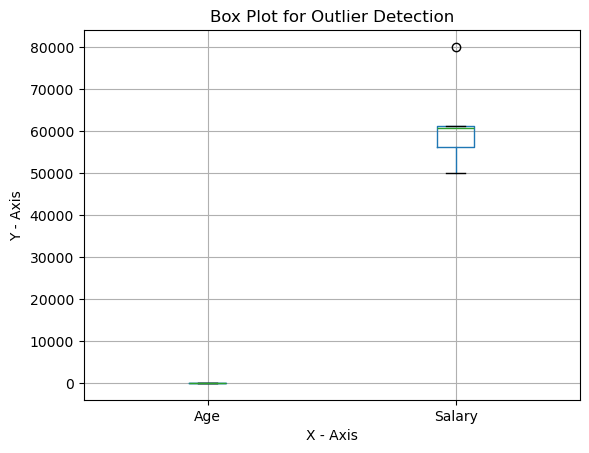

In [48]:
import matplotlib.pyplot as plt
plt.title("Box Plot for Outlier Detection")
plt.xlabel("X - Axis")
plt.ylabel("Y - Axis")
df[['Age','Salary']].boxplot()
plt.show()

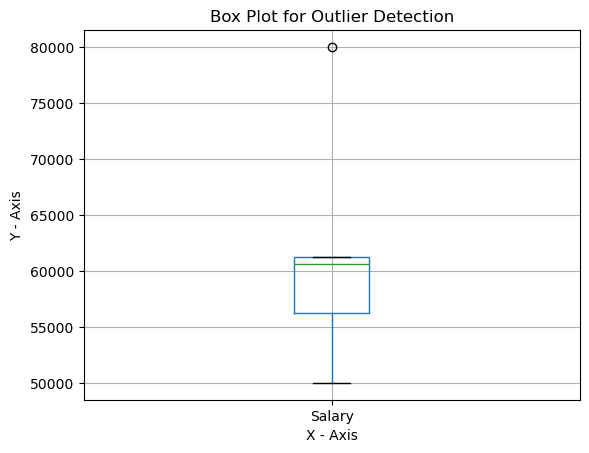

In [46]:
import matplotlib.pyplot as plt
plt.title("Box Plot for Outlier Detection")
plt.xlabel("X - Axis")
plt.ylabel("Y - Axis")
df.boxplot(column='Salary')
plt.show()

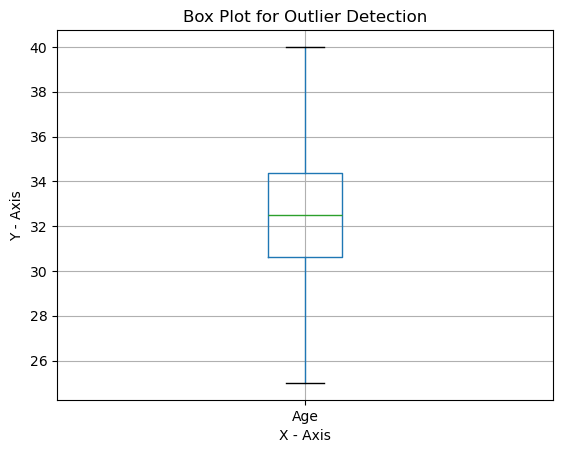

In [47]:
import matplotlib.pyplot as plt
plt.title("Box Plot for Outlier Detection")
plt.xlabel("X - Axis")
plt.ylabel("Y - Axis")
df.boxplot(column='Age')
plt.show()

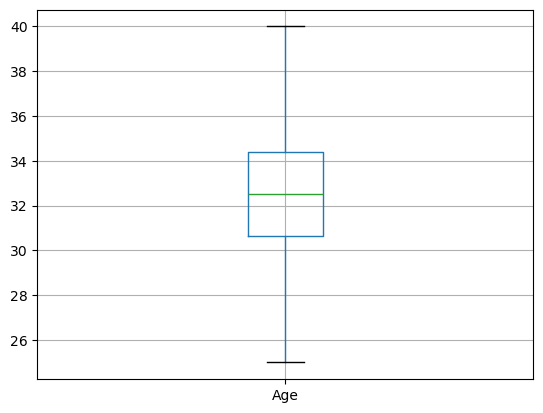

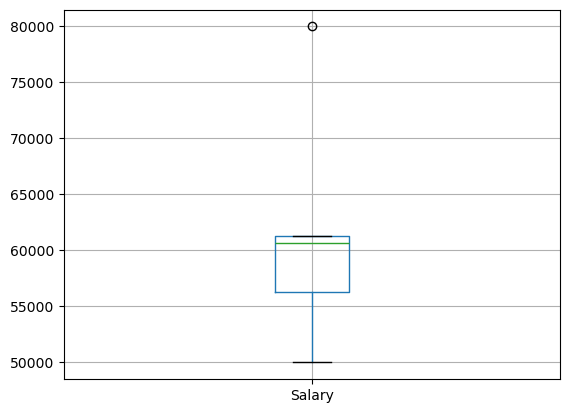

In [41]:
plt.figure()
df.boxplot(column='Age')

plt.figure()
df.boxplot(column='Salary')

plt.show()


# Data Type Conversion

In [46]:
import pandas as pd
import numpy as np

data = {
    'Age': ['25', '30', '35', '40', 'unknown'],
    'Salary': ['50000', '60000', '55000', '80000', '90000'],
    'Purchased': ['yes', 'no', 'yes', 'no', 'yes']
}

df = pd.DataFrame(data)
print(df.dtypes)
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')
df['Salary'] = pd.to_numeric(df['Salary'], errors='coerce')
df

Age          object
Salary       object
Purchased    object
dtype: object


,Age,Salary,Purchased
0,25.0,50000,yes
1,30.0,60000,no
2,35.0,55000,yes
3,40.0,80000,no
4,NaN,90000,yes


In [47]:
df.dtypes

Age          float64
Salary         int64
Purchased     object
dtype: object